In [1]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', 25)
pd.set_option('display.max_columns', 20)

data = pd.read_csv('./data/data.csv', delimiter=',')
data.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [2]:
desc = data.describe().T
desc

,count,mean,std,min,25%,50%,75%,max
Bankrupt?,6819.0,0.032263,0.176710,0.0,0.000000,0.000000,0.000000,1.0
ROA(C) before interest and depreciation before interest,6819.0,0.505180,0.060686,0.0,0.476527,0.502706,0.535563,1.0
ROA(A) before interest and % after tax,6819.0,0.558625,0.065620,0.0,0.535543,0.559802,0.589157,1.0
ROA(B) before interest and depreciation after tax,6819.0,0.553589,0.061595,0.0,0.527277,0.552278,0.584105,1.0
Operating Gross Margin,6819.0,0.607948,0.016934,0.0,0.600445,0.605997,0.613914,1.0
...,...,...,...,...,...,...,...,...
Liability to Equity,6819.0,0.280365,0.014463,0.0,0.276944,0.278778,0.281449,1.0
Degree of Financial Leverage (DFL),6819.0,0.027541,0.015668,0.0,0.026791,0.026808,0.026913,1.0
Interest Coverage Ratio (Interest expense to EBIT),6819.0,0.565358,0.013214,0.0,0.565158,0.565252,0.565725,1.0
Net Income Flag,6819.0,1.000000,0.000000,1.0,1.000000,1.000000,1.000000,1.0


La maggior parte delle variabili hanno minino 0 e massimo 1 -> assumono valori in [0, 1]. Altre invece non sono scalate, procediamo quindi a scalare queste variabili. Prima di scalarle, applichiamo un /sigma clipping per il rilevamento di eventuali outliers.

In [3]:
#prendiamo le feature che hanno un valore massimo diverso da 1 -> praticamente il subset non scalato
not_scaled_cols = desc[desc['max'] != 1].index
not_scaled_data = data[not_scaled_cols]
not_scaled_data

,Operating Expense Rate,Research and development expense rate,Interest-bearing debt interest rate,Revenue Per Share (Yuan ¥),Total Asset Growth Rate,Net Value Growth Rate,Current Ratio,Quick Ratio,Total debt/Total net worth,Accounts Receivable Turnover,...,Allocation rate per person,Quick Assets/Current Liability,Cash/Current Liability,Inventory/Current Liability,Long-term Liability to Current Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Cash Turnover Rate,Fixed Assets to Assets,Total assets to GNP price
0,1.256969e-04,0.000000e+00,7.250725e-04,0.017560,4.980000e+09,0.000327,0.002259,0.001208,0.021266,0.001814,...,0.037135,0.001997,1.473360e-04,0.001036,2.559237e-02,7.010000e+08,6.550000e+09,4.580000e+08,0.424206,0.009219
1,2.897851e-04,0.000000e+00,6.470647e-04,0.021144,6.110000e+09,0.000443,0.006016,0.004039,0.012502,0.001286,...,0.012335,0.004136,1.383910e-03,0.005210,2.394682e-02,1.065198e-04,7.700000e+09,2.490000e+09,0.468828,0.008323
2,2.361297e-04,2.550000e+07,7.900790e-04,0.005944,7.280000e+09,0.000396,0.011543,0.005348,0.021248,0.001495,...,0.141016,0.006302,5.340000e+09,0.013879,3.715116e-03,1.791094e-03,1.022676e-03,7.610000e+08,0.276179,0.040003
3,1.078888e-04,0.000000e+00,4.490449e-04,0.014368,4.880000e+09,0.000382,0.004194,0.002896,0.009572,0.001966,...,0.021320,0.002961,1.010646e-03,0.003540,2.216520e-02,8.140000e+09,6.050000e+09,2.030000e+09,0.559144,0.003252
4,7.890000e+09,0.000000e+00,6.860686e-04,0.029690,5.510000e+09,0.000439,0.006022,0.003727,0.005150,0.001449,...,0.023988,0.004275,6.804636e-04,0.004869,0.000000e+00,6.680000e+09,5.050000e+09,8.240000e+08,0.309555,0.003878
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6814,1.510213e-04,4.500000e+09,1.790179e-04,0.020766,7.070000e+09,0.000450,0.010451,0.005457,0.006655,0.000690,...,0.006312,0.005469,5.071548e-03,0.013212,1.792237e-03,2.294154e-04,1.244230e-04,1.077940e-04,0.400338,0.000466
6815,5.220000e+09,1.440000e+09,2.370237e-04,0.023050,5.220000e+09,0.000445,0.009259,0.006741,0.004623,0.000655,...,0.003401,0.006790,4.727181e-03,0.006730,2.204673e-03,1.517299e-04,1.173396e-04,7.710000e+09,0.096136,0.001959
6816,2.509312e-04,1.039086e-04,0.000000e+00,0.044255,5.990000e+09,0.000435,0.038424,0.035112,0.001392,0.001510,...,0.002774,0.035531,8.821248e-02,0.007810,0.000000e+00,1.762272e-04,1.749713e-04,4.074263e-04,0.055509,0.002840
6817,1.236154e-04,2.510000e+09,2.110211e-04,0.031535,7.250000e+09,0.000529,0.012782,0.007256,0.003816,0.000716,...,0.007489,0.007753,7.133218e-03,0.013334,3.200000e+09,2.135940e-04,1.351937e-04,1.165392e-04,0.246805,0.002837


In [4]:
desc_ns = not_scaled_data.describe()
desc_ns

,Operating Expense Rate,Research and development expense rate,Interest-bearing debt interest rate,Revenue Per Share (Yuan ¥),Total Asset Growth Rate,Net Value Growth Rate,Current Ratio,Quick Ratio,Total debt/Total net worth,Accounts Receivable Turnover,...,Allocation rate per person,Quick Assets/Current Liability,Cash/Current Liability,Inventory/Current Liability,Long-term Liability to Current Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Cash Turnover Rate,Fixed Assets to Assets,Total assets to GNP price
count,6.819000e+03,6.819000e+03,6.819000e+03,6.819000e+03,6.819000e+03,6.819000e+03,6.819000e+03,6.819000e+03,6.819000e+03,6.819000e+03,...,6.819000e+03,6.819000e+03,6.819000e+03,6.819000e+03,6.819000e+03,6.819000e+03,6.819000e+03,6.819000e+03,6.819000e+03,6.819000e+03
mean,1.995347e+09,1.950427e+09,1.644801e+07,1.328641e+06,5.508097e+09,1.566212e+06,4.032850e+05,8.376595e+06,4.416337e+06,1.278971e+07,...,1.125579e+07,3.592902e+06,3.715999e+07,5.580680e+07,5.416004e+07,1.195856e+09,2.163735e+09,2.471977e+09,1.220121e+06,1.862942e+07
std,3.237684e+09,2.598292e+09,1.082750e+08,5.170709e+07,2.897718e+09,1.141594e+08,3.330216e+07,2.446847e+08,1.684069e+08,2.782598e+08,...,2.945063e+08,1.716209e+08,5.103509e+08,5.820516e+08,5.702706e+08,2.821161e+09,3.374944e+09,2.938623e+09,1.007542e+08,3.764501e+08
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.566874e-04,1.281880e-04,2.030203e-04,1.563138e-02,4.860000e+09,4.409689e-04,7.555047e-03,4.725903e-03,3.007049e-03,7.101336e-04,...,4.120529e-03,5.239776e-03,1.973008e-03,3.163148e-03,0.000000e+00,1.456236e-04,1.417149e-04,2.735337e-04,8.536037e-02,9.036205e-04
50%,2.777589e-04,5.090000e+08,3.210321e-04,2.737571e-02,6.400000e+09,4.619555e-04,1.058717e-02,7.412472e-03,5.546284e-03,9.678107e-04,...,7.844373e-03,7.908898e-03,4.903886e-03,6.497335e-03,1.974619e-03,1.987816e-04,2.247728e-04,1.080000e+09,1.968810e-01,2.085213e-03
75%,4.145000e+09,3.450000e+09,5.325533e-04,4.635722e-02,7.390000e+09,4.993621e-04,1.626953e-02,1.224911e-02,9.273293e-03,1.454759e-03,...,1.502031e-02,1.295091e-02,1.280557e-02,1.114677e-02,9.005946e-03,4.525945e-04,4.900000e+09,4.510000e+09,3.722000e-01,5.269777e-03
max,9.990000e+09,9.980000e+09,9.900000e+08,3.020000e+09,9.990000e+09,9.330000e+09,2.750000e+09,9.230000e+09,9.940000e+09,9.740000e+09,...,9.570000e+09,8.820000e+09,9.650000e+09,9.910000e+09,9.540000e+09,1.000000e+10,1.000000e+10,1.000000e+10,8.320000e+09,9.820000e+09


In [10]:
from sklearn.preprocessing import StandardScaler

# Creiamo una copia del dataset originale
data_scaled = data.copy()

# Inizializziamo lo scaler
scaler = StandardScaler()

# Scaliamo SOLO le 24 colonne che ne hanno bisogno
data_scaled[not_scaled_cols] = scaler.fit_transform(data_scaled[not_scaled_cols])

# Stampiamo le statistiche descrittive per verificare che abbia funzionato.
desc_scaled = data_scaled[not_scaled_cols].describe().round(3)
desc_scaled

,Operating Expense Rate,Research and development expense rate,Interest-bearing debt interest rate,Revenue Per Share (Yuan ¥),Total Asset Growth Rate,Net Value Growth Rate,Current Ratio,Quick Ratio,Total debt/Total net worth,Accounts Receivable Turnover,...,Allocation rate per person,Quick Assets/Current Liability,Cash/Current Liability,Inventory/Current Liability,Long-term Liability to Current Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Cash Turnover Rate,Fixed Assets to Assets,Total assets to GNP price
count,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,...,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000
mean,0.000,0.000,-0.000,-0.000,0.000,-0.000,0.000,0.000,-0.000,-0.000,...,-0.000,0.000,0.000,-0.000,-0.000,-0.000,0.000,0.000,-0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,...,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-0.616,-0.751,-0.152,-0.026,-1.901,-0.014,-0.012,-0.034,-0.026,-0.046,...,-0.038,-0.021,-0.073,-0.096,-0.095,-0.424,-0.641,-0.841,-0.012,-0.049
25%,-0.616,-0.751,-0.152,-0.026,-0.224,-0.014,-0.012,-0.034,-0.026,-0.046,...,-0.038,-0.021,-0.073,-0.096,-0.095,-0.424,-0.641,-0.841,-0.012,-0.049
50%,-0.616,-0.555,-0.152,-0.026,0.308,-0.014,-0.012,-0.034,-0.026,-0.046,...,-0.038,-0.021,-0.073,-0.096,-0.095,-0.424,-0.641,-0.474,-0.012,-0.049
75%,0.664,0.577,-0.152,-0.026,0.649,-0.014,-0.012,-0.034,-0.026,-0.046,...,-0.038,-0.021,-0.073,-0.096,-0.095,-0.424,0.811,0.694,-0.012,-0.049
max,2.469,3.091,8.992,58.385,1.547,81.720,82.571,37.691,59.002,34.960,...,32.459,51.375,18.837,16.931,16.635,3.121,2.322,2.562,82.571,26.038


In questa sezione esploriamo visivamente il dataset:
1. Lo sbilanciamento delle classi
2. L'importanza delle variabili
3. Distribuzione (Boxplot)

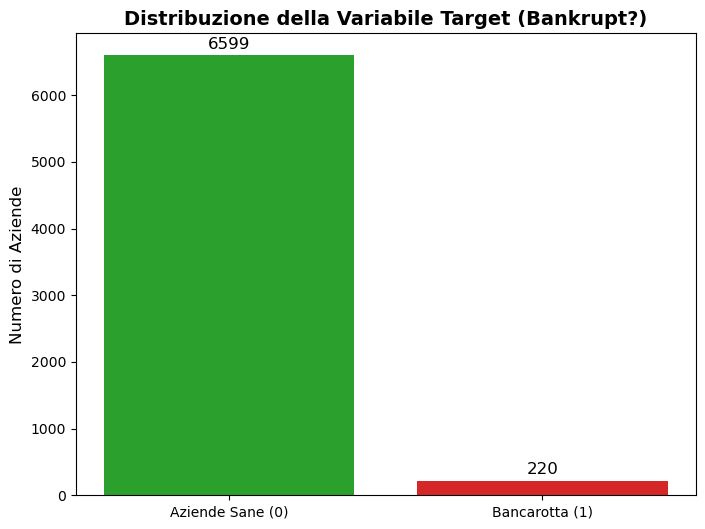

In [11]:
plt.figure(figsize=(8, 6))

counts = data_scaled['Bankrupt?'].value_counts()
labels = ['Aziende Sane (0)', 'Bancarotta (1)']
colors = ['#2ca02c', '#d62728']

bars = plt.bar(labels, counts.values, color=colors)
plt.title('Distribuzione della Variabile Target (Bankrupt?)', fontsize=14, fontweight='bold')
plt.ylabel('Numero di Aziende', fontsize=12)

# Aggiungiamo i numeri esatti sopra le barre
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, int(yval), ha='center', va='bottom', fontsize=12)

plt.show()

Il dataset è fortemente sbilanciato. I casi di bancarotta rappresentano appena il 3.2% del totale.

(per più  in la conviene utilizzare Recall, Balanced Accuracy e F1-Score.)

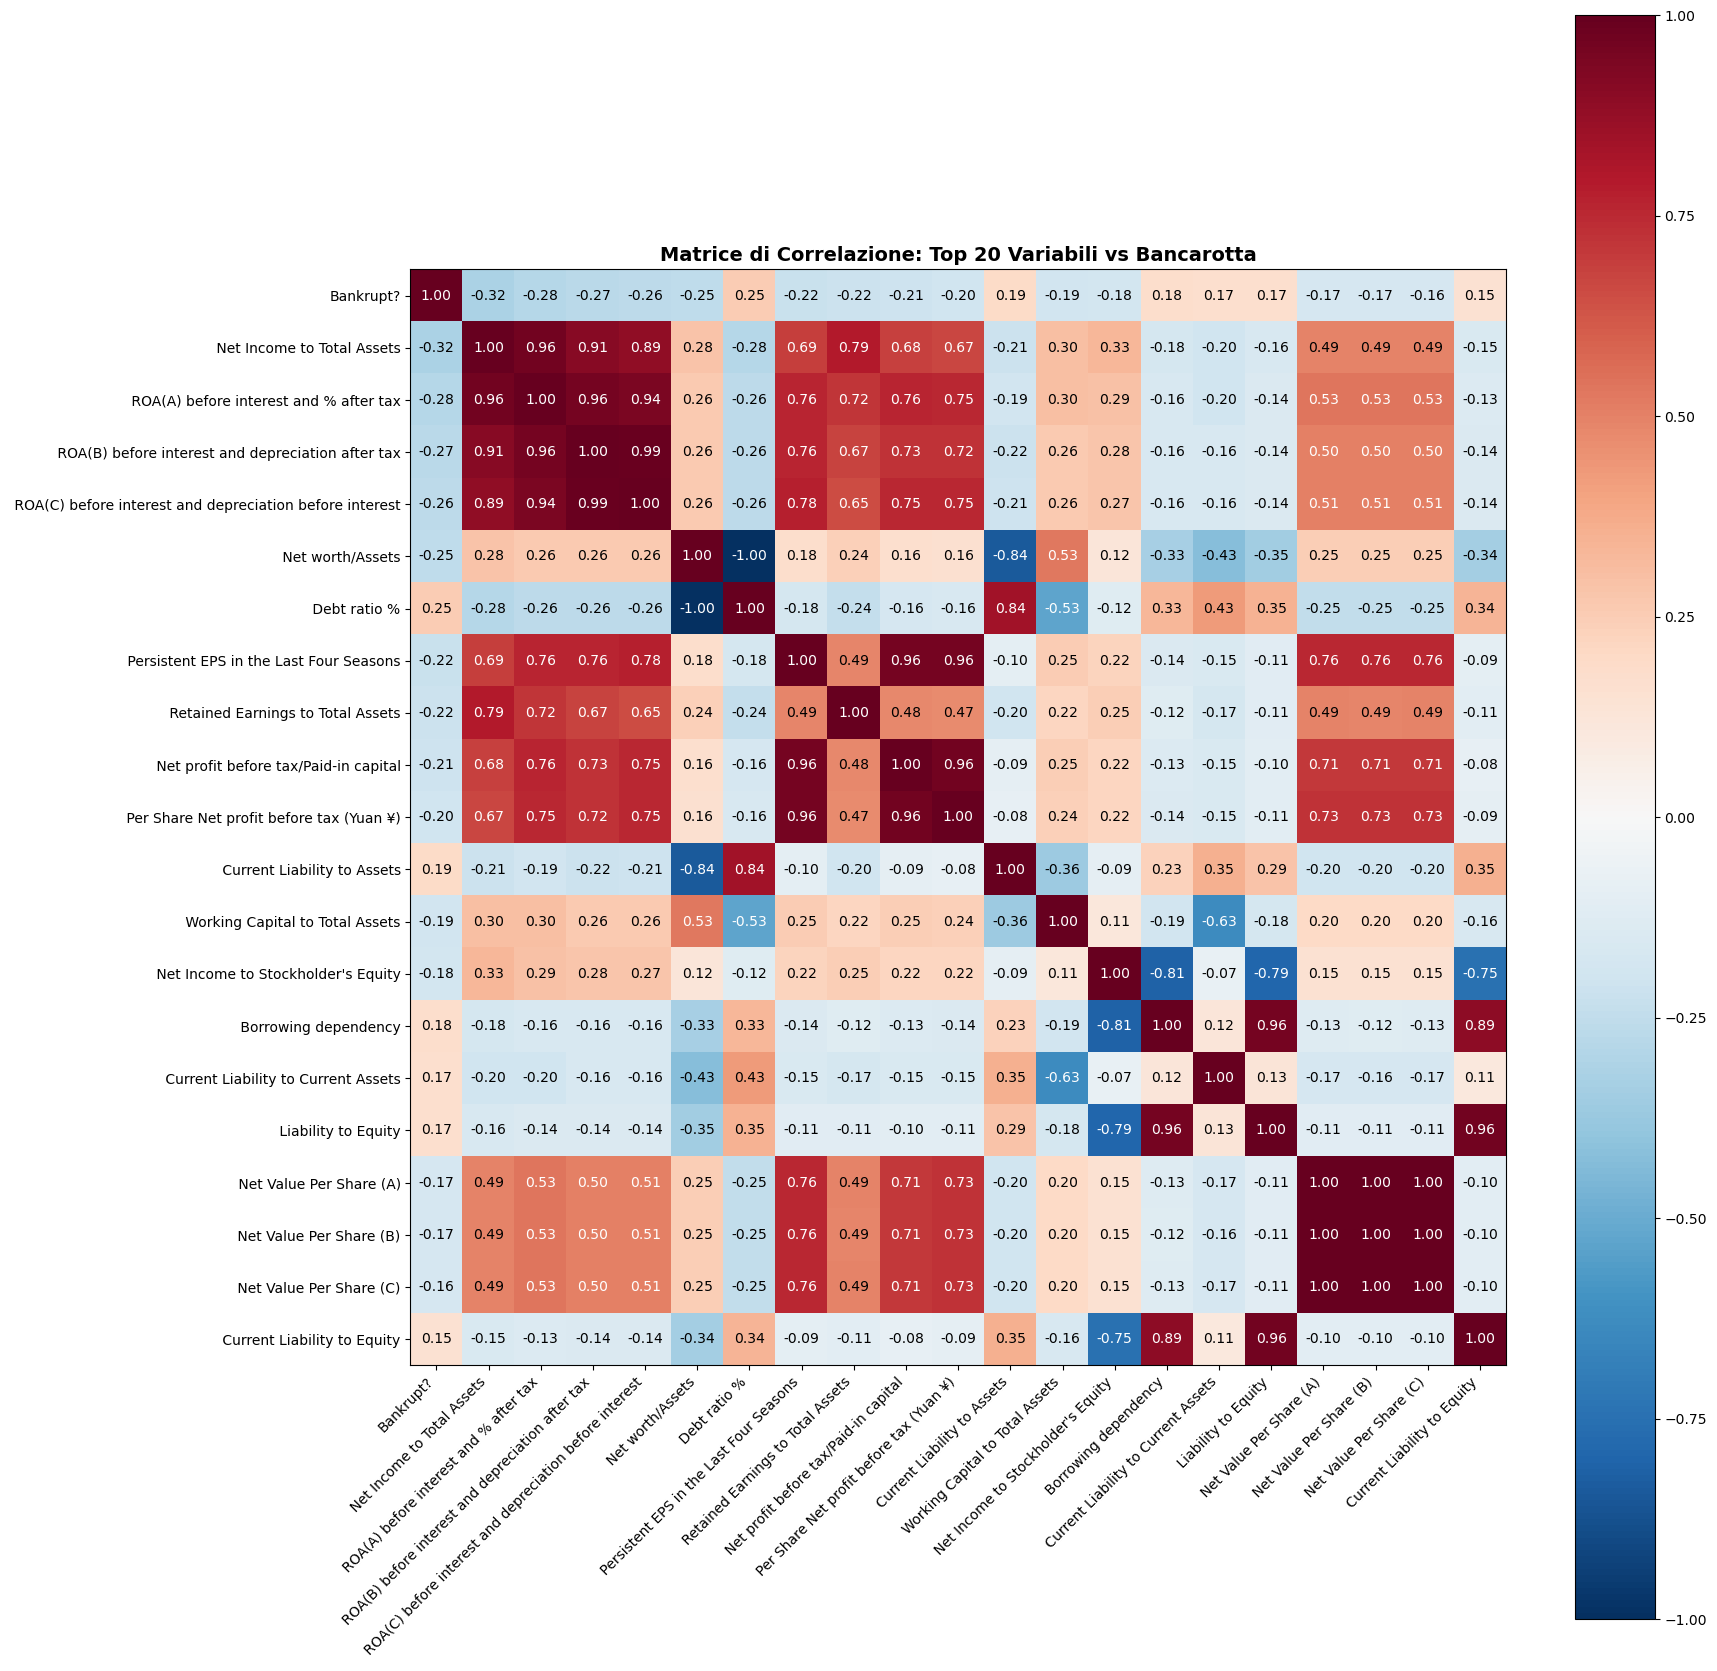

In [19]:
correlations = data_scaled.corr()['Bankrupt?'].drop('Bankrupt?')

# Prendiamo le 20 variabili con la correlazione (in valore assoluto) più alta
top_20_features = correlations.abs().sort_values(ascending=False).head(20).index
cols_to_plot = ['Bankrupt?'] + list(top_20_features)
corr_matrix = data_scaled[cols_to_plot].corr()

fig, ax = plt.subplots(figsize=(18, 18))
# Usiamo imshow di matplotlib per creare la heatmap
cax = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
fig.colorbar(cax)

# Impostiamo le etichette per gli assi
ax.set_xticks(np.arange(len(cols_to_plot)))
ax.set_yticks(np.arange(len(cols_to_plot)))
ax.set_xticklabels(cols_to_plot, rotation=45, ha='right')
ax.set_yticklabels(cols_to_plot)

# Aggiungiamo i valori numerici all'interno dei quadrati
for i in range(len(cols_to_plot)):
    for j in range(len(cols_to_plot)):
        # Cambiamo il colore del testo per renderlo leggibile sullo sfondo
        text_color = "white" if abs(corr_matrix.iloc[i, j]) > 0.5 else "black"
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                ha="center", va="center", color=text_color)

plt.title('Matrice di Correlazione: Top 20 Variabili vs Bancarotta', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Net Income to Total Assets è il più forte: quando i profitti rispetto agli asset scendono, la probabilità di bancarotta sale nettamente

C:\Users\HP\AppData\Local\Temp\ipykernel_16944\3319414715.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot([sane, fallite], labels=labels, patch_artist=True)


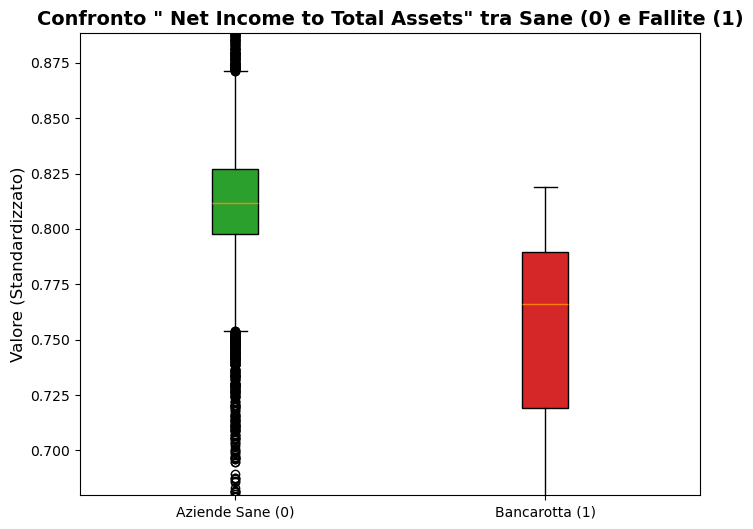

In [20]:
top_feature = top_20_features[0]

sane = data_scaled[data_scaled['Bankrupt?'] == 0][top_feature]
fallite = data_scaled[data_scaled['Bankrupt?'] == 1][top_feature]

plt.figure(figsize=(8, 6))
bplot = plt.boxplot([sane, fallite], labels=labels, patch_artist=True)

for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

plt.title(f'Confronto "{top_feature}" tra Sane (0) e Fallite (1)', fontsize=14, fontweight='bold')
plt.ylabel('Valore (Standardizzato)', fontsize=12)

plt.ylim(data_scaled[top_feature].quantile(0.01), data_scaled[top_feature].quantile(0.99))

plt.show()

Questo boxplot mette a confronto le distribuzioni delle aziende sane e in bancarotta rispetto alla variabile "Net Income to Total Assets".

1. La distribuzione delle aziende fallite è significativamente traslata verso il basso rispetto a quella delle aziende sane. Un'incapacità di generare utile netto rispetto al volume delle attività totali rappresenta il primo e più affidabile campanello d'allarme del dissesto finanziario.

2. Si osserva un'elevata concentrazione di outliers sotto la distribuzione delle aziende sane. Questi record rappresentano imprese che, pur registrando perdite d'esercizio severe (Net Income fortemente negativo), non sono fallite. Economicalmente, ciò accade quando l'azienda dispone di ampie riserve di liquidità accumulate in passato, o gode di un basso livello di indebitamento complessivo.  

Il nostro dataset presenta un forte sbilanciamento. Proviamo due approcci distinti e ne confronteremo le performance sul Test Set:

1. Modello A (Cost-Sensitive Learning):** Nessuna alterazione fisica dei dati. Penalità maggiori agli errori sulla classe minoritaria.
2. Modello B (SMOTE): Generiamo aziende fallite sintetiche nel Training Set per raggiungere una proporzione 50/50, mantenendo il Test Set intatto e reale per una valutazione oggettiva.

Come modello di base per questo confronto utilizzeremo la Regressione Logistica. La valutazione si baserà su Balanced Accuracy, Recall (capacità di intercettare i fallimenti) e F1-Score.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE

X = data_scaled.drop('Bankrupt?', axis=1)
y = data_scaled['Bankrupt?']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Distribuzione Train Originale -> Sane: {len(y_train)-y_train.sum()} | Bancarotte: {y_train.sum()}")
print(f"Distribuzione Test Set        -> Sane: {len(y_test)-y_test.sum()} | Bancarotte: {y_test.sum()}\n")


Distribuzione Train Originale -> Sane: 5279 | Bancarotte: 176
Distribuzione Test Set        -> Sane: 1320 | Bancarotte: 44



In [37]:
# Funzione di utilità per stampare le metriche
def stampa_metriche(y_true, y_pred, nome_modello):
    print(f"=== {nome_modello} ===")
    print(f"Balanced Accuracy: {balanced_accuracy_score(y_true, y_pred):.3f}")
    print(f"Recall:            {recall_score(y_true, y_pred):.3f}  <-- % di fallimenti reali individuati")
    print(f"Precision:         {precision_score(y_true, y_pred):.3f}")
    print(f"F1-Score:          {f1_score(y_true, y_pred):.3f}")
    print(f"ROC-AUC:           {roc_auc_score(y_true, y_pred):.3f}")
    print("Matrice di Confusione:")
    print(confusion_matrix(y_true, y_pred).transpose())

In [38]:
modello_A = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)
modello_A.fit(X_train, y_train)

y_pred_A = modello_A.predict(X_test)
stampa_metriche(y_test, y_pred_A, "MODELLO A (Regressione Logistica con Pesi Bilanciati)")

=== MODELLO A (Regressione Logistica con Pesi Bilanciati) ===
Balanced Accuracy: 0.865
Recall:            0.864  <-- % di fallimenti reali individuati
Precision:         0.177
F1-Score:          0.293
ROC-AUC:           0.865
Matrice di Confusione:
[[1143    6]
 [ 177   38]]


In [43]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Distribuzione Train con SMOTE -> Sane: {len(y_train_smote)-y_train_smote.sum()} | Bancarotte: {y_train_smote.sum()}\n")

modello_B = LogisticRegression(max_iter=2000, random_state=42)
modello_B.fit(X_train_smote, y_train_smote)

y_pred_B = modello_B.predict(X_test)
stampa_metriche(y_test, y_pred_B, "MODELLO B (Regressione Logistica addestrata su dati SMOTE)")

Distribuzione Train con SMOTE -> Sane: 5279 | Bancarotte: 5279

=== MODELLO B (Regressione Logistica addestrata su dati SMOTE) ===
Balanced Accuracy: 0.850
Recall:            0.818  <-- % di fallimenti reali individuati
Precision:         0.188
F1-Score:          0.306
ROC-AUC:           0.850
Matrice di Confusione:
[[1165    8]
 [ 155   36]]
